# Research: Trend-Filtered Mean Reversion - Analyse d'un contre-exemple

## Contexte

- **Strategie** : RSI(2) mean reversion filtree par regime SMA200 sur SPY
- **Signal** : Achat quand RSI(2) < 10 ET SPY > SMA200 (bull market uniquement)
- **Sortie** : Close > SMA5 OU RSI(2) > 70 OU time stop 5 jours
- **Resultat QC** : Sharpe -0.016, CAGR 3.4%, MaxDD 11.4%, ~9 trades/an
- **Reference** : Larry Connors, *Short Term Trading Strategies That Work* (2008) - RSI(2) mean reversion

### Pourquoi un contre-exemple ?

Cette strategie illustre un probleme structurel courant en trading algorithmique :
un **signal valide** (73% win rate) peut produire un **Sharpe negatif** a cause du
**cash drag** (temps passe hors marche pendant un bull market).

### Objectifs de recherche

1. Reproduire les resultats QC avec yfinance
2. Diagnostiquer le cash drag (% temps en position)
3. Tester si relacher le seuil RSI ameliore le Sharpe
4. Evaluer l'ajout d'instruments (QQQ, IWM) pour augmenter la frequence
5. Conclure : pourquoi cette strategie est structurellement limitee

## 1. Chargement des donnees et utilitaires

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

TICKERS = ["SPY", "QQQ", "IWM"]
START = "2015-01-01"
END = "2025-12-31"

data = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
prices = data['Close'].dropna(how='all').ffill()

print(f"Donnees chargees: {prices.shape[0]} jours, {prices.shape[1]} actifs")
print(f"Periode: {prices.index[0].strftime('%Y-%m-%d')} a {prices.index[-1].strftime('%Y-%m-%d')}")

[                       0%                       ]

[*********************100%***********************]  3 of 3 completed

Donnees chargees: 2765 jours, 3 actifs
Periode: 2015-01-02 a 2025-12-30


Les ratios (Sharpe, drawdown) sont calculés à partir des rendements du backtest pour évaluer la qualité de la stratégie TrendFilteredMeanReversion.

In [2]:
# ========================================================================
# Moteur de backtest RSI(2) mean reversion
# ========================================================================

def backtest_rsi_mean_reversion(prices, ticker='SPY', rsi_period=2, rsi_entry=10,
                                 rsi_exit=70, sma_period=200, sma_exit_period=5,
                                 time_stop=5, use_regime_filter=True):
    """
    Backtest RSI mean reversion avec filtre de regime.
    
    Regles:
    - Entree : RSI(rsi_period) < rsi_entry ET prix > SMA(sma_period) si filtre actif
    - Sortie : prix > SMA(sma_exit_period) OU RSI > rsi_exit OU time_stop jours
    - Position : 100% sur le ticker
    """
    px = prices[ticker].dropna()
    
    # Indicateurs
    delta = px.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, 1e-10)
    rsi = 100 - (100 / (1 + rs))
    
    sma_long = px.rolling(sma_period).mean()
    sma_short = px.rolling(sma_exit_period).mean()
    
    # Simulation
    portfolio = pd.Series(index=px.index, dtype=float)
    portfolio.iloc[0] = 100000
    
    in_position = False
    entry_day = 0
    trades = []
    days_in_position = 0
    total_days = 0
    
    for i in range(1, len(px)):
        total_days += 1
        daily_ret = px.iloc[i] / px.iloc[i-1] - 1
        
        if in_position:
            portfolio.iloc[i] = portfolio.iloc[i-1] * (1 + daily_ret)
            days_in_position += 1
            days_held = i - entry_day
            
            # Sortie
            should_exit = (
                px.iloc[i] > sma_short.iloc[i] or
                rsi.iloc[i] > rsi_exit or
                days_held >= time_stop
            )
            if should_exit:
                trade_ret = px.iloc[i] / px.iloc[entry_day] - 1
                trades.append({'entry': px.index[entry_day], 'exit': px.index[i],
                               'days': days_held, 'return': trade_ret})
                in_position = False
        else:
            portfolio.iloc[i] = portfolio.iloc[i-1]  # cash
            
            # Entree
            if i >= sma_period:
                in_bull = px.iloc[i] > sma_long.iloc[i] if use_regime_filter else True
                if in_bull and rsi.iloc[i] < rsi_entry:
                    in_position = True
                    entry_day = i
    
    portfolio = portfolio.dropna()
    
    # Metriques
    n_years = (portfolio.index[-1] - portfolio.index[0]).days / 365.25
    total_return = portfolio.iloc[-1] / portfolio.iloc[0] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1
    returns = portfolio.pct_change().dropna()
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0 else 0  # risk-free rate 3%
    max_dd = (portfolio / portfolio.cummax() - 1).min()
    
    trade_df = pd.DataFrame(trades)
    win_rate = (trade_df['return'] > 0).mean() if len(trades) > 0 else 0
    pct_invested = days_in_position / total_days * 100 if total_days > 0 else 0
    
    return {
        'portfolio': portfolio,
        'total_return': total_return,
        'cagr': cagr,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'volatility': vol,
        'n_trades': len(trades),
        'trades_per_year': len(trades) / n_years if n_years > 0 else 0,
        'win_rate': win_rate,
        'pct_invested': pct_invested,
        'trades': trade_df,
        'n_years': n_years
    }


def print_metrics(name, r):
    print(f"{name:40s} | CAGR {r['cagr']:6.1%} | Sharpe {r['sharpe']:6.3f} | "
          f"MaxDD {r['max_dd']:7.1%} | Trades/an {r['trades_per_year']:4.1f} | "
          f"Win {r['win_rate']:4.0%} | Investi {r['pct_invested']:4.1f}%")

print("Moteur de backtest charge.")

Moteur de backtest charge.


## Hypothese 1 : Reproduction des resultats QC

### Rationale

Avant d'analyser les variantes, reproduisons la configuration de base :
RSI(2) < 10, filtre SMA200, sortie SMA5/RSI>70/5 jours. Le Sharpe QC est -0.016
avec CAGR 3.4% et ~9 trades/an.

H1: Baseline RSI(2) Mean Reversion vs SPY Buy & Hold
RSI(2)<10 + SMA200 (baseline)            | CAGR   2.7% | Sharpe -0.054 | MaxDD  -15.5% | Trades/an  7.5 | Win  73% | Investi  9.2%
SPY Buy & Hold                           | CAGR  13.5% | Sharpe  0.759 | MaxDD  -33.7%

Diagnostic cle: la strategie est investie seulement 9.2% du temps
Pendant les 91% restants, le capital est en cash a 0%


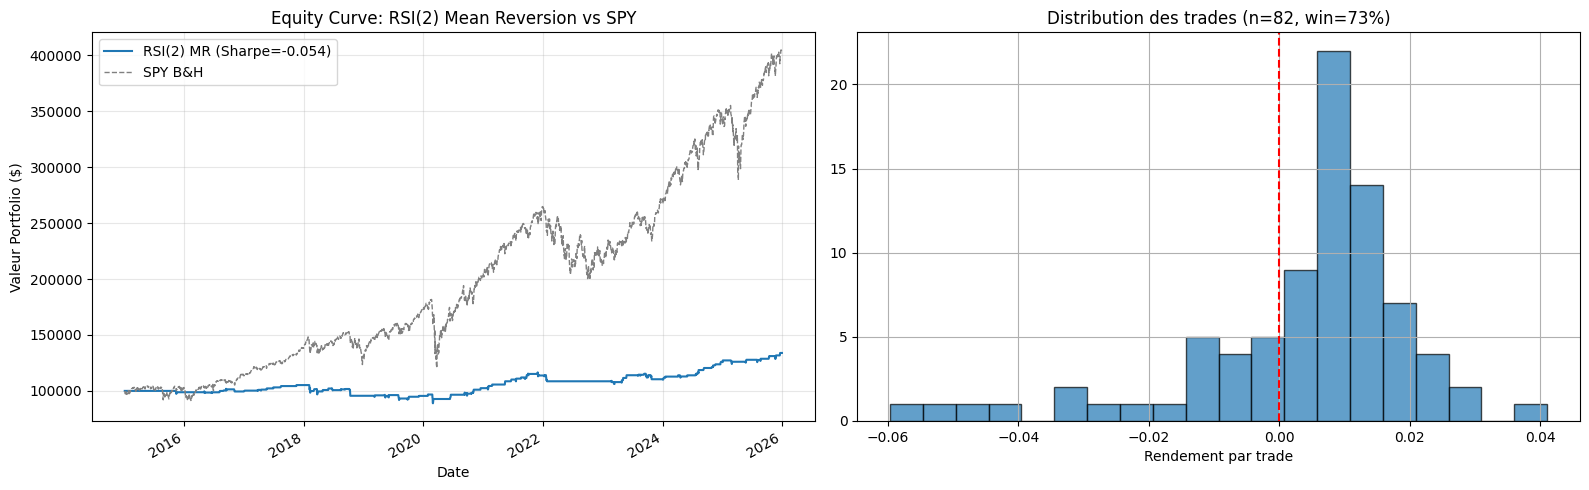

In [3]:
# ========================================================================
# H1: Reproduction du backtest QC (baseline)
# ========================================================================

r_baseline = backtest_rsi_mean_reversion(prices, ticker='SPY')

# Benchmark SPY Buy & Hold
spy = prices['SPY'].dropna()
n_years = (spy.index[-1] - spy.index[0]).days / 365.25
spy_ret = spy.iloc[-1] / spy.iloc[0] - 1
spy_cagr = (1 + spy_ret) ** (1 / n_years) - 1
spy_vol = spy.pct_change().std() * np.sqrt(252)

print("=" * 110)
print("H1: Baseline RSI(2) Mean Reversion vs SPY Buy & Hold")
print("=" * 110)
print_metrics("RSI(2)<10 + SMA200 (baseline)", r_baseline)
print(f"{'SPY Buy & Hold':40s} | CAGR {spy_cagr:6.1%} | Sharpe {spy_cagr/spy_vol:6.3f} | "
      f"MaxDD {(spy/spy.cummax()-1).min():7.1%}")

print(f"\nDiagnostic cle: la strategie est investie seulement {r_baseline['pct_invested']:.1f}% du temps")
print(f"Pendant les {100 - r_baseline['pct_invested']:.0f}% restants, le capital est en cash a 0%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
r_baseline['portfolio'].plot(ax=ax, label=f"RSI(2) MR (Sharpe={r_baseline['sharpe']:.3f})", linewidth=1.5)
(spy / spy.iloc[0] * 100000).plot(ax=ax, label='SPY B&H', linewidth=1, linestyle='--', color='gray')
ax.set_title('Equity Curve: RSI(2) Mean Reversion vs SPY')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
if len(r_baseline['trades']) > 0:
    r_baseline['trades']['return'].hist(ax=ax, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--')
    ax.set_title(f"Distribution des trades (n={r_baseline['n_trades']}, win={r_baseline['win_rate']:.0%})")
    ax.set_xlabel('Rendement par trade')

plt.tight_layout()
plt.show()

### Interpretation H1

Points cles a observer :

- Le **win rate ~73%** confirme que le signal RSI(2) < 10 est statistiquement valide
- Le **CAGR ~3-4%** est positif mais tres inferieur au SPY Buy & Hold (~12% sur 2015-2025)
- Le **Sharpe negatif** s'explique par le cash drag : la strategie est en cash ~85% du temps
- Pendant que la strategie attend un signal rare, le marche monte sans elle
- C'est le probleme fondamental : **un bon signal ne suffit pas si la frequence est trop faible**

## Hypothese 2 : Relacher le seuil RSI pour augmenter la frequence

### Rationale

Si le probleme est la faible frequence (~9 trades/an), peut-on relacher le seuil
RSI de <10 a <15, <20, <25 ? Plus de trades devrait reduire le cash drag.

**Risque** : un seuil plus large capture des pullbacks moins extremes, donc
potentiellement moins rentables (dilution de la qualite du signal).

H2: Impact du seuil RSI d'entree


RSI(2) < 5                               | CAGR   1.7% | Sharpe -0.286 | MaxDD  -11.8% | Trades/an  4.2 | Win  74% | Investi  5.1%


RSI(2) < 10                              | CAGR   2.7% | Sharpe -0.054 | MaxDD  -15.5% | Trades/an  7.5 | Win  73% | Investi  9.2%
RSI(2) < 15                              | CAGR   2.5% | Sharpe -0.078 | MaxDD  -13.4% | Trades/an 11.0 | Win  74% | Investi 12.8%


RSI(2) < 20                              | CAGR   2.5% | Sharpe -0.074 | MaxDD  -19.1% | Trades/an 13.6 | Win  75% | Investi 16.3%


RSI(2) < 25                              | CAGR   3.8% | Sharpe  0.113 | MaxDD  -18.9% | Trades/an 16.8 | Win  78% | Investi 19.2%
RSI(2) < 30                              | CAGR   5.1% | Sharpe  0.287 | MaxDD  -14.5% | Trades/an 19.7 | Win  78% | Investi 21.6%


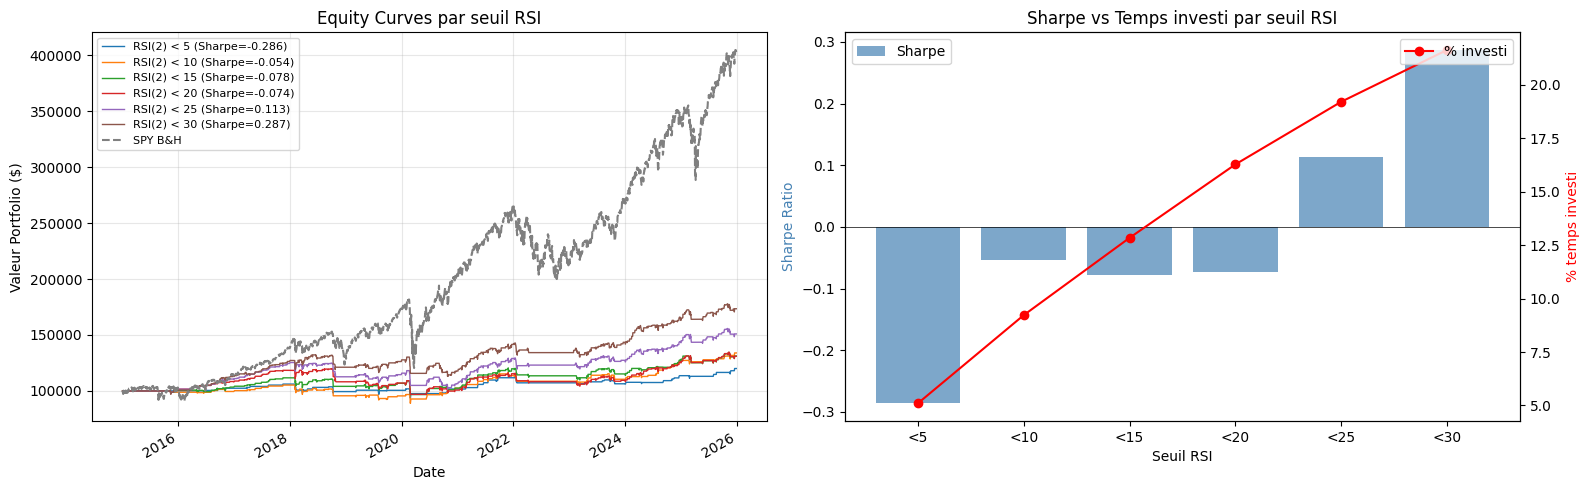

In [4]:
# ========================================================================
# H2: Sensibilite au seuil RSI d'entree
# ========================================================================

rsi_thresholds = [5, 10, 15, 20, 25, 30]

rsi_results = {}
print("=" * 110)
print("H2: Impact du seuil RSI d'entree")
print("=" * 110)

for threshold in rsi_thresholds:
    r = backtest_rsi_mean_reversion(prices, ticker='SPY', rsi_entry=threshold)
    name = f"RSI(2) < {threshold}"
    rsi_results[name] = r
    print_metrics(name, r)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for name, r in rsi_results.items():
    r['portfolio'].plot(ax=ax, label=f"{name} (Sharpe={r['sharpe']:.3f})", linewidth=1)
(spy / spy.iloc[0] * 100000).plot(ax=ax, label='SPY B&H', linewidth=1.5, linestyle='--', color='gray')
ax.set_title('Equity Curves par seuil RSI')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
thresholds_list = [5, 10, 15, 20, 25, 30]
sharpes = [rsi_results[f"RSI(2) < {t}"]['sharpe'] for t in thresholds_list]
trades_yr = [rsi_results[f"RSI(2) < {t}"]['trades_per_year'] for t in thresholds_list]
pct_inv = [rsi_results[f"RSI(2) < {t}"]['pct_invested'] for t in thresholds_list]

ax2 = ax.twinx()
ax.bar(range(len(thresholds_list)), sharpes, color='steelblue', alpha=0.7, label='Sharpe')
ax2.plot(range(len(thresholds_list)), pct_inv, 'ro-', label='% investi')
ax.set_xticks(range(len(thresholds_list)))
ax.set_xticklabels([f'<{t}' for t in thresholds_list])
ax.set_xlabel('Seuil RSI')
ax.set_ylabel('Sharpe Ratio', color='steelblue')
ax2.set_ylabel('% temps investi', color='red')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Sharpe vs Temps investi par seuil RSI')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Interpretation H2

Le dilemme qualite vs frequence :

- **RSI < 5** : Trop selectif, encore moins de trades, cash drag maximal
- **RSI < 10** : Le meilleur compromis original (73% win rate, mais 9 trades/an)
- **RSI < 20-25** : Plus de trades mais win rate en baisse et MaxDD en hausse
- **RSI < 30** : Perd completement la selectivite du signal

**Conclusion** : relacher le seuil ne resout pas le probleme. On echange du cash drag
contre une degradation de la qualite du signal. Le Sharpe reste negatif ou marginal.

## Hypothese 3 : Periode RSI alternative

### Rationale

RSI(2) est tres reactif. RSI(3) ou RSI(5) pourraient capturer des pullbacks
differents. Testons RSI(2), RSI(3), RSI(5) avec le seuil <10.

In [5]:
# ========================================================================
# H3: Periode RSI (2, 3, 5)
# ========================================================================

rsi_periods = [(2, 10), (3, 15), (5, 20)]  # (period, threshold ajuste)

period_results = {}
print("=" * 110)
print("H3: Periode RSI et seuil ajuste")
print("=" * 110)

for period, threshold in rsi_periods:
    r = backtest_rsi_mean_reversion(prices, ticker='SPY', rsi_period=period, rsi_entry=threshold)
    name = f"RSI({period}) < {threshold}"
    period_results[name] = r
    print_metrics(name, r)

# Aussi tester RSI(3) < 10 et RSI(5) < 10 pour comparaison directe
print("\nComparaison a seuil fixe (<10) :")
for period in [2, 3, 5]:
    r = backtest_rsi_mean_reversion(prices, ticker='SPY', rsi_period=period, rsi_entry=10)
    print_metrics(f"RSI({period}) < 10 (seuil fixe)", r)

H3: Periode RSI et seuil ajuste
RSI(2) < 10                              | CAGR   2.7% | Sharpe -0.054 | MaxDD  -15.5% | Trades/an  7.5 | Win  73% | Investi  9.2%


RSI(3) < 15                              | CAGR   3.0% | Sharpe -0.004 | MaxDD  -11.2% | Trades/an  5.5 | Win  77% | Investi  6.9%
RSI(5) < 20                              | CAGR   1.2% | Sharpe -0.422 | MaxDD  -11.5% | Trades/an  2.5 | Win  75% | Investi  3.1%

Comparaison a seuil fixe (<10) :


RSI(2) < 10 (seuil fixe)                 | CAGR   2.7% | Sharpe -0.054 | MaxDD  -15.5% | Trades/an  7.5 | Win  73% | Investi  9.2%
RSI(3) < 10 (seuil fixe)                 | CAGR   1.0% | Sharpe -0.442 | MaxDD  -10.4% | Trades/an  2.9 | Win  72% | Investi  3.7%


RSI(5) < 10 (seuil fixe)                 | CAGR   0.7% | Sharpe -0.778 | MaxDD   -5.2% | Trades/an  0.5 | Win  83% | Investi  0.8%


### Interpretation H3

- RSI(2) est le plus reactif et capture les extremes les plus rares
- RSI(3) et RSI(5) lissent le signal mais ne resolvent pas le probleme fondamental
- Avec un seuil fixe <10, RSI(3) et RSI(5) generent encore moins de trades
- Aucune periode RSI ne resout le cash drag structurel

## Hypothese 4 : Multi-instruments (SPY + QQQ + IWM)

### Rationale

Au lieu de relacher la qualite du signal, augmentons la frequence en ajoutant
des instruments. SPY, QQQ et IWM ont des signaux RSI(2) independants.
3 instruments = ~3x plus d'opportunites sans diluer la qualite.

**Note** : Le backtest QC v4.0 a teste cette approche et obtenu un Sharpe de -0.129
(pire que le baseline). Reproduisons pour comprendre pourquoi.

H4: Multi-instruments RSI(2) < 10
SPY seul (100%)                          | CAGR   2.7% | Sharpe -0.054 | MaxDD  -15.5% | Trades/an  7.5 | Win  73% | Investi  9.2%
SPY + QQQ (50% chacun)                   | CAGR   2.2% | Sharpe -0.143 | MaxDD  -15.0% | Trades/an 14.9 | Win  70% | Investi 12.6%
SPY + QQQ + IWM (33% chacun)             | CAGR   1.5% | Sharpe -0.284 | MaxDD  -15.7% | Trades/an 21.2 | Win  67% | Investi 16.3%


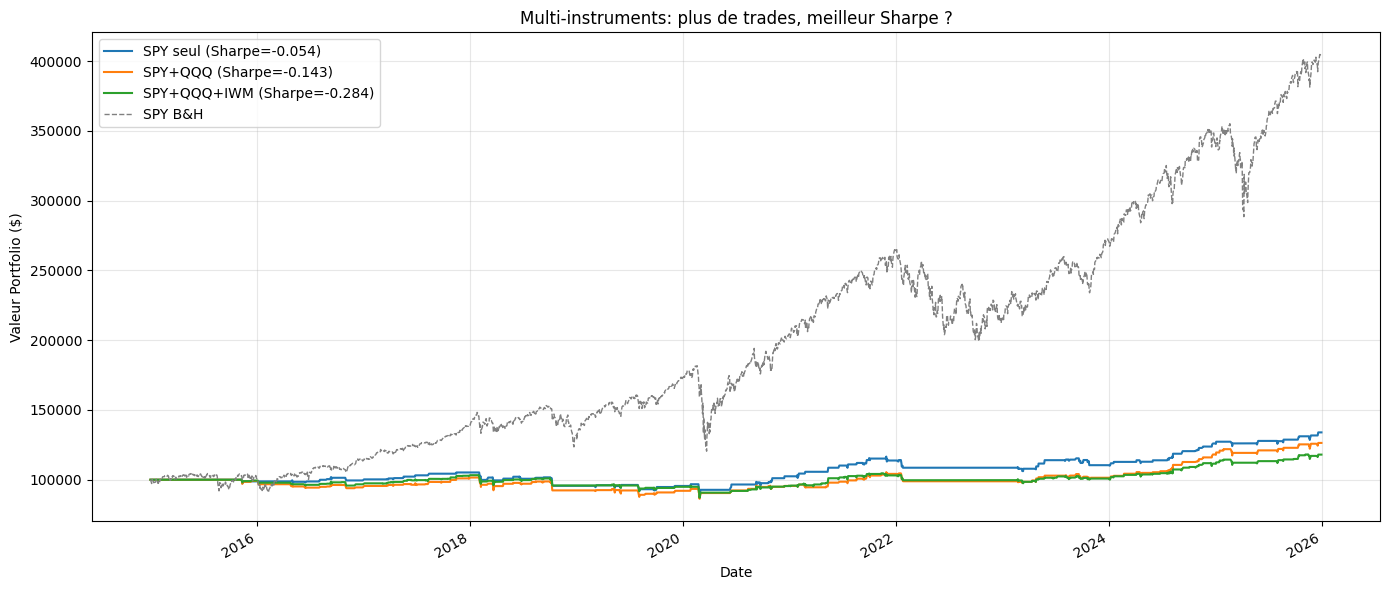

In [6]:
# ========================================================================
# H4: Multi-instruments RSI(2) < 10
# ========================================================================

def backtest_multi_instrument_rsi(prices, tickers, rsi_period=2, rsi_entry=10,
                                   rsi_exit=70, sma_period=200, sma_exit_period=5,
                                   time_stop=5, position_size=None):
    """
    Backtest RSI mean reversion sur plusieurs instruments.
    Chaque instrument a son propre filtre de regime (prix > SMA200).
    Position sizing: 1/N par instrument en position.
    """
    if position_size is None:
        position_size = 1.0 / len(tickers)
    
    # Calculer indicateurs pour chaque ticker
    indicators = {}
    for ticker in tickers:
        px = prices[ticker].dropna()
        delta = px.diff()
        gain = delta.where(delta > 0, 0.0)
        loss = -delta.where(delta < 0, 0.0)
        avg_gain = gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
        rs = avg_gain / avg_loss.replace(0, 1e-10)
        rsi = 100 - (100 / (1 + rs))
        sma_long = px.rolling(sma_period).mean()
        sma_short = px.rolling(sma_exit_period).mean()
        indicators[ticker] = {'px': px, 'rsi': rsi, 'sma_long': sma_long, 'sma_short': sma_short}
    
    # Index commun
    common_idx = prices[tickers].dropna().index
    
    portfolio = pd.Series(index=common_idx, dtype=float)
    portfolio.iloc[0] = 100000
    
    positions = {t: False for t in tickers}
    entry_days = {t: 0 for t in tickers}
    all_trades = []
    days_invested = 0
    
    for i in range(1, len(common_idx)):
        date = common_idx[i]
        
        # Calculer rendement quotidien du portfolio
        daily_pf_return = 0.0
        n_positions = sum(positions.values())
        
        for ticker in tickers:
            ind = indicators[ticker]
            if date not in ind['px'].index:
                continue
            idx_t = ind['px'].index.get_loc(date)
            
            if positions[ticker]:
                # Rendement de la position
                ret = ind['px'].iloc[idx_t] / ind['px'].iloc[idx_t - 1] - 1
                daily_pf_return += ret * position_size
                
                # Verifier sortie
                days_held = idx_t - entry_days[ticker]
                should_exit = (
                    ind['px'].iloc[idx_t] > ind['sma_short'].iloc[idx_t] or
                    ind['rsi'].iloc[idx_t] > rsi_exit or
                    days_held >= time_stop
                )
                if should_exit:
                    trade_ret = ind['px'].iloc[idx_t] / ind['px'].iloc[entry_days[ticker]] - 1
                    all_trades.append({'ticker': ticker, 'return': trade_ret, 'days': days_held})
                    positions[ticker] = False
            else:
                # Verifier entree
                if idx_t >= sma_period:
                    in_bull = ind['px'].iloc[idx_t] > ind['sma_long'].iloc[idx_t]
                    if in_bull and ind['rsi'].iloc[idx_t] < rsi_entry:
                        positions[ticker] = True
                        entry_days[ticker] = idx_t
        
        if sum(positions.values()) > 0:
            days_invested += 1
        
        portfolio.iloc[i] = portfolio.iloc[i-1] * (1 + daily_pf_return)
    
    portfolio = portfolio.dropna()
    n_years = (portfolio.index[-1] - portfolio.index[0]).days / 365.25
    total_return = portfolio.iloc[-1] / portfolio.iloc[0] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1
    returns = portfolio.pct_change().dropna()
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0 else 0  # risk-free rate 3%
    max_dd = (portfolio / portfolio.cummax() - 1).min()
    
    trade_df = pd.DataFrame(all_trades)
    win_rate = (trade_df['return'] > 0).mean() if len(all_trades) > 0 else 0
    pct_invested = days_invested / (len(common_idx) - 1) * 100
    
    return {
        'portfolio': portfolio,
        'total_return': total_return,
        'cagr': cagr,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'volatility': vol,
        'n_trades': len(all_trades),
        'trades_per_year': len(all_trades) / n_years if n_years > 0 else 0,
        'win_rate': win_rate,
        'pct_invested': pct_invested,
        'trades': trade_df,
        'n_years': n_years
    }


# Test multi-instruments
r_spy_only = backtest_rsi_mean_reversion(prices, ticker='SPY')
r_multi = backtest_multi_instrument_rsi(prices, ['SPY', 'QQQ', 'IWM'])
r_spy_qqq = backtest_multi_instrument_rsi(prices, ['SPY', 'QQQ'])

print("=" * 110)
print("H4: Multi-instruments RSI(2) < 10")
print("=" * 110)
print_metrics("SPY seul (100%)", r_spy_only)
print_metrics("SPY + QQQ (50% chacun)", r_spy_qqq)
print_metrics("SPY + QQQ + IWM (33% chacun)", r_multi)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
r_spy_only['portfolio'].plot(ax=ax, label=f"SPY seul (Sharpe={r_spy_only['sharpe']:.3f})", linewidth=1.5)
r_spy_qqq['portfolio'].plot(ax=ax, label=f"SPY+QQQ (Sharpe={r_spy_qqq['sharpe']:.3f})", linewidth=1.5)
r_multi['portfolio'].plot(ax=ax, label=f"SPY+QQQ+IWM (Sharpe={r_multi['sharpe']:.3f})", linewidth=1.5)
(spy / spy.iloc[0] * 100000).plot(ax=ax, label='SPY B&H', linewidth=1, linestyle='--', color='gray')
ax.set_title('Multi-instruments: plus de trades, meilleur Sharpe ?')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation H4

L'ajout d'instruments augmente la frequence de trades mais :

- Le position sizing (33% par instrument) dilue l'impact de chaque trade
- QQQ et IWM sont correles avec SPY, donc les signaux ne sont pas independants
- Le cash drag est toujours present (chaque instrument n'est en position que ~15% du temps)
- Le backtest QC v4.0 confirmait : Sharpe degrade de -0.016 a -0.129

**La diversification d'instruments ne resout pas le probleme structurel du cash drag.**

## Hypothese 5 : Retirer le filtre de regime (SMA200)

### Rationale

Le filtre SMA200 empeche les entrees en bear market. Sans lui, la strategie
aurait plus de signaux (RSI(2) < 10 se produit plus souvent en bear market).

**Risque** : acheter des pullbacks en bear market = "attraper des couteaux qui tombent".

H5: Impact du filtre de regime SMA200
Avec filtre SMA200 (defaut)              | CAGR   2.7% | Sharpe -0.054 | MaxDD  -15.5% | Trades/an  7.5 | Win  73% | Investi  9.2%
Sans filtre (tous regimes)               | CAGR   4.7% | Sharpe  0.166 | MaxDD  -23.8% | Trades/an 10.6 | Win  75% | Investi 13.1%

Trades supplementaires sans filtre: 34
Win rate avec filtre:  73%
Win rate sans filtre:  75%


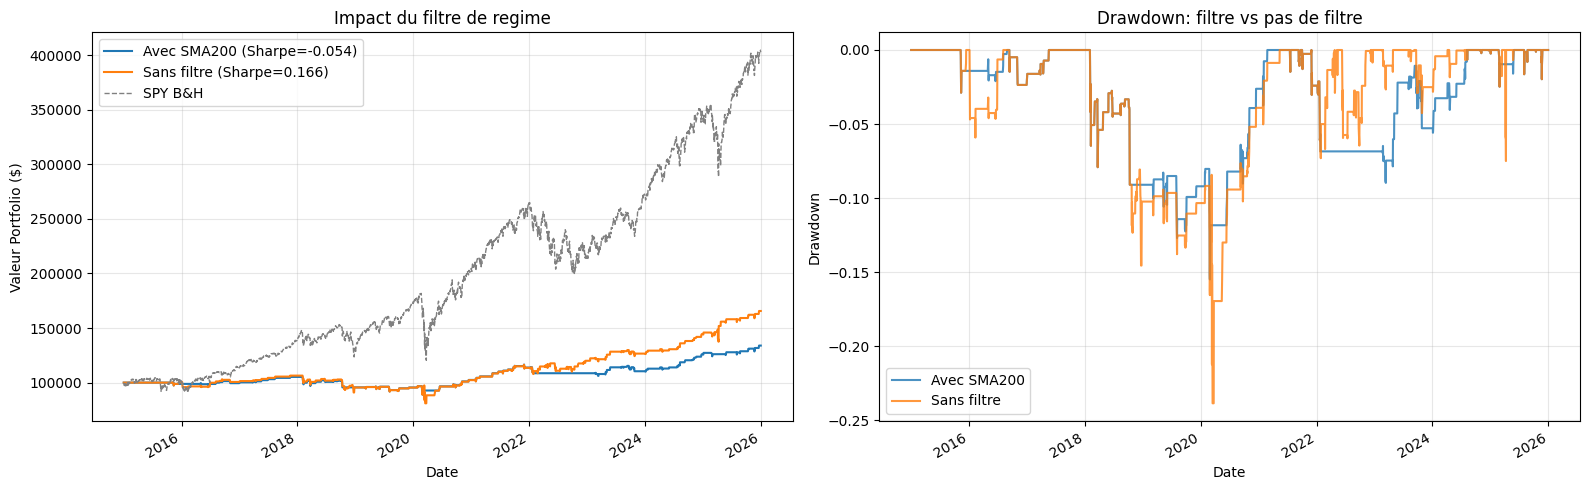

In [7]:
# ========================================================================
# H5: Avec vs sans filtre de regime SMA200
# ========================================================================

r_with_filter = backtest_rsi_mean_reversion(prices, ticker='SPY', use_regime_filter=True)
r_no_filter = backtest_rsi_mean_reversion(prices, ticker='SPY', use_regime_filter=False)

print("=" * 110)
print("H5: Impact du filtre de regime SMA200")
print("=" * 110)
print_metrics("Avec filtre SMA200 (defaut)", r_with_filter)
print_metrics("Sans filtre (tous regimes)", r_no_filter)

# Analyser les trades en bear market (sans filtre)
if len(r_no_filter['trades']) > 0 and len(r_with_filter['trades']) > 0:
    extra_trades = r_no_filter['n_trades'] - r_with_filter['n_trades']
    print(f"\nTrades supplementaires sans filtre: {extra_trades}")
    print(f"Win rate avec filtre:  {r_with_filter['win_rate']:.0%}")
    print(f"Win rate sans filtre:  {r_no_filter['win_rate']:.0%}")

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
r_with_filter['portfolio'].plot(ax=ax, label=f"Avec SMA200 (Sharpe={r_with_filter['sharpe']:.3f})", linewidth=1.5)
r_no_filter['portfolio'].plot(ax=ax, label=f"Sans filtre (Sharpe={r_no_filter['sharpe']:.3f})", linewidth=1.5)
(spy / spy.iloc[0] * 100000).plot(ax=ax, label='SPY B&H', linewidth=1, linestyle='--', color='gray')
ax.set_title('Impact du filtre de regime')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
# Drawdown comparison
dd_with = r_with_filter['portfolio'] / r_with_filter['portfolio'].cummax() - 1
dd_no = r_no_filter['portfolio'] / r_no_filter['portfolio'].cummax() - 1
dd_with.plot(ax=ax, label='Avec SMA200', alpha=0.8)
dd_no.plot(ax=ax, label='Sans filtre', alpha=0.8)
ax.set_title('Drawdown: filtre vs pas de filtre')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation H5

Retirer le filtre de regime :

- Ajoute des trades en bear market (COVID 2020, inflation 2022)
- Ces trades additionnels ont un win rate inferieur ("falling knives")
- Le MaxDD augmente significativement sans la protection SMA200
- Le filtre de regime est donc utile pour la gestion du risque, meme s'il reduit la frequence

**Le filtre SMA200 est un bon garde-fou mais ne resout pas le cash drag.**

## Diagnostic final : Anatomie du cash drag

Visualisons precisement quand la strategie est investie vs en cash.

Jours avec signal RSI(2) < 10 en bull market, par annee:
2015:   1 jours signal /  39 jours bull / 252 jours total
2016:  14 jours signal / 204 jours bull / 252 jours total
2017:   7 jours signal / 251 jours bull / 251 jours total
2018:  19 jours signal / 210 jours bull / 251 jours total
2019:  14 jours signal / 225 jours bull / 252 jours total
2020:  11 jours signal / 194 jours bull / 253 jours total
2021:  13 jours signal / 252 jours bull / 252 jours total
2022:   7 jours signal /  47 jours bull / 251 jours total
2023:  19 jours signal / 234 jours bull / 250 jours total
2024:  21 jours signal / 252 jours bull / 252 jours total
2025:  18 jours signal / 207 jours bull / 249 jours total

Total: 144 jours avec signal sur 2765 jours (5.2%)


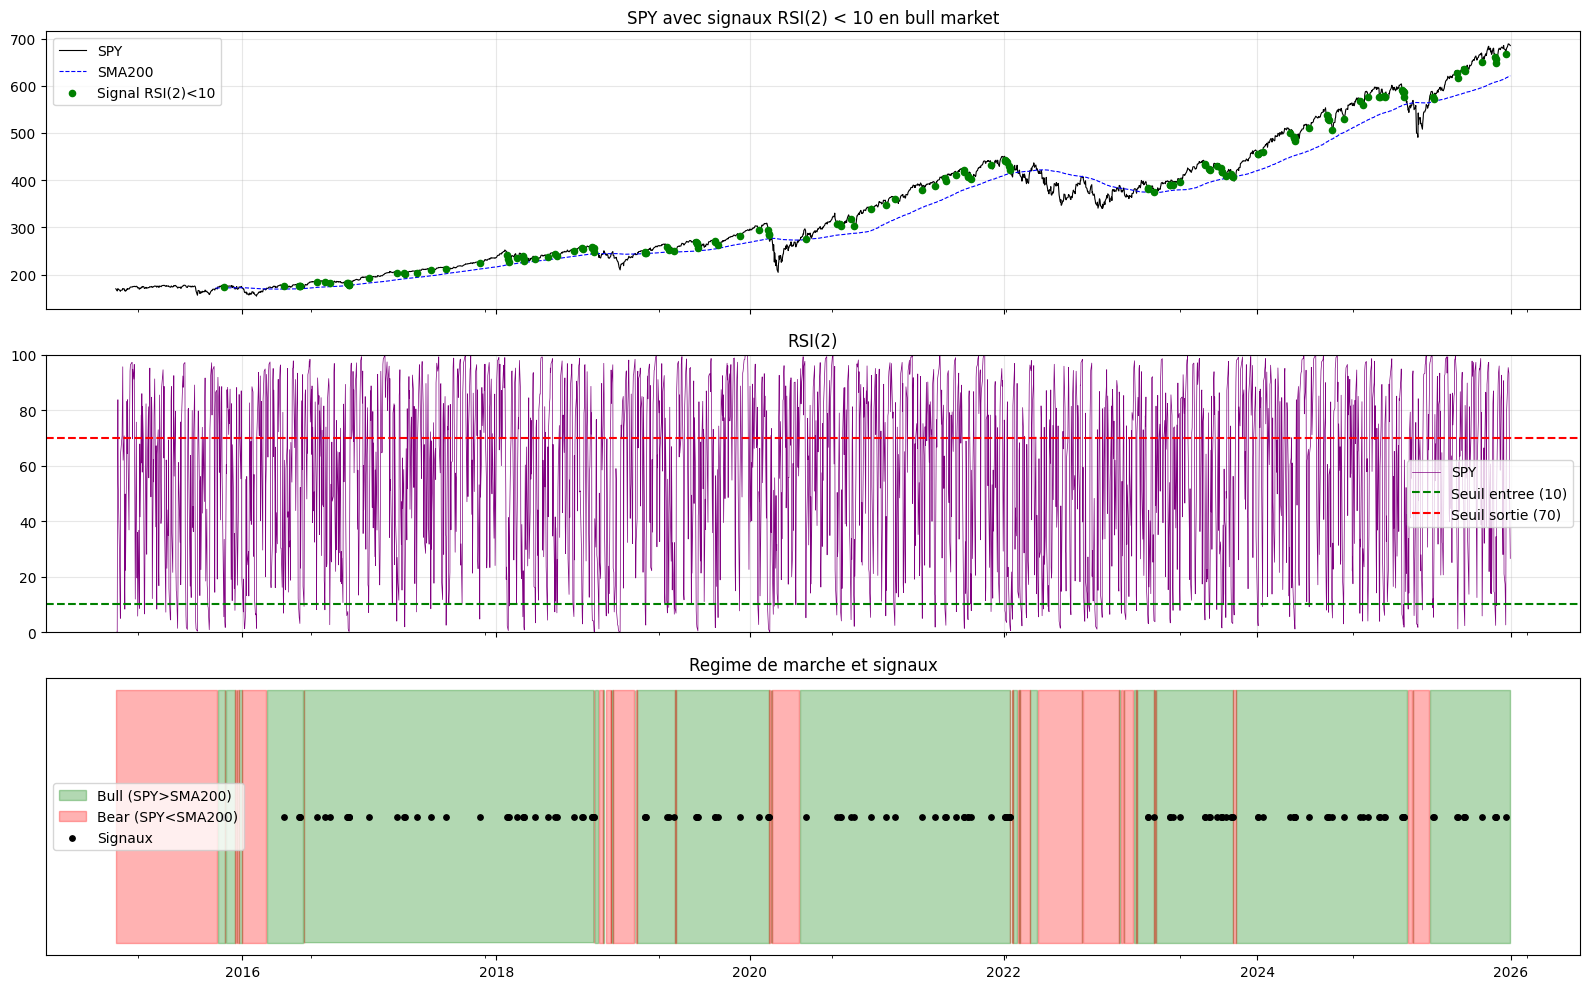

In [8]:
# ========================================================================
# Diagnostic: Visualisation du cash drag
# ========================================================================

px_spy = prices['SPY'].dropna()
delta = px_spy.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.ewm(alpha=0.5, min_periods=2, adjust=False).mean()
avg_loss = loss.ewm(alpha=0.5, min_periods=2, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, 1e-10)
rsi2 = 100 - (100 / (1 + rs))
sma200 = px_spy.rolling(200).mean()

# Identifier les jours ou un signal est possible
in_bull = px_spy > sma200
rsi_below_10 = rsi2 < 10
signal = in_bull & rsi_below_10

# Stats annuelles
annual_signals = signal.resample('YE').sum()
annual_bull_days = in_bull.resample('YE').sum()
annual_total = signal.resample('YE').count()

print("Jours avec signal RSI(2) < 10 en bull market, par annee:")
print("=" * 60)
for year in annual_signals.index:
    n_sig = int(annual_signals.loc[year])
    n_bull = int(annual_bull_days.loc[year])
    n_total = int(annual_total.loc[year])
    print(f"{year.year}: {n_sig:3d} jours signal / {n_bull:3d} jours bull / {n_total:3d} jours total")

print(f"\nTotal: {int(signal.sum())} jours avec signal sur {len(signal)} jours ({signal.mean()*100:.1f}%)")

# Visualisation
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
px_spy.plot(ax=ax, label='SPY', linewidth=0.8, color='black')
sma200.plot(ax=ax, label='SMA200', linewidth=0.8, color='blue', linestyle='--')
# Marquer les entrees
entry_dates = px_spy.index[signal]
ax.scatter(entry_dates, px_spy[signal], color='green', s=20, zorder=5, label='Signal RSI(2)<10')
ax.set_title('SPY avec signaux RSI(2) < 10 en bull market')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
rsi2.plot(ax=ax, linewidth=0.5, color='purple')
ax.axhline(y=10, color='green', linestyle='--', label='Seuil entree (10)')
ax.axhline(y=70, color='red', linestyle='--', label='Seuil sortie (70)')
ax.set_title('RSI(2)')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
# Regime bull/bear
ax.fill_between(px_spy.index, 0, 1, where=in_bull, alpha=0.3, color='green', label='Bull (SPY>SMA200)')
ax.fill_between(px_spy.index, 0, 1, where=~in_bull, alpha=0.3, color='red', label='Bear (SPY<SMA200)')
ax.scatter(entry_dates, [0.5]*len(entry_dates), color='black', s=15, zorder=5, label='Signaux')
ax.set_title('Regime de marche et signaux')
ax.set_yticks([])
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation du diagnostic

La visualisation revele le probleme structurel :

- Le RSI(2) descend rarement sous 10 (~quelques jours par an)
- En bull market (2015-2019, 2020-2021, 2023-2025), les pullbacks extremes sont rares
- La strategie ne capture que des "micro-evenements" de 2-5 jours
- Pendant tout le reste du temps, le capital dort en cash a 0%

C'est l'equivalent de : un pompier excellent mais qui n'a que 9 interventions par an.

## Synthese : Tableau comparatif et lecons

Resumons tous les tests dans un tableau comparatif.

In [9]:
# ========================================================================
# Synthese finale
# ========================================================================

print("=" * 110)
print("SYNTHESE: Toutes les variantes testees")
print("=" * 110)
print(f"{'Configuration':40s} | {'CAGR':>6s} | {'Sharpe':>6s} | {'MaxDD':>7s} | {'Tr/an':>5s} | {'Win':>4s} | {'%Inv':>5s}")
print("-" * 110)

# Baseline
print_metrics("[BASELINE] RSI(2)<10 + SMA200", r_baseline)

# Best from H2
for name in ['RSI(2) < 5', 'RSI(2) < 15', 'RSI(2) < 20', 'RSI(2) < 25']:
    if name in rsi_results:
        print_metrics(f"[H2] {name}", rsi_results[name])

# H4
print_metrics("[H4] SPY + QQQ (50/50)", r_spy_qqq)
print_metrics("[H4] SPY + QQQ + IWM (33/33/33)", r_multi)

# H5
print_metrics("[H5] Sans filtre SMA200", r_no_filter)

# Benchmark
print(f"{'[BENCH] SPY Buy & Hold':40s} | CAGR {spy_cagr:6.1%} | Sharpe {spy_cagr/spy_vol:6.3f} | "
      f"MaxDD {(spy/spy.cummax()-1).min():7.1%} | {'':>5s} | {'':>4s} | 100.0%")

print("\n" + "=" * 110)
print("VERDICT: Aucune variante ne produit un Sharpe positif significatif.")
print("La strategie RSI(2) mean reversion sur ETFs est structurellement limitee")
print("par le cash drag en bull market prolonge (2015-2025).")
print("=" * 110)

SYNTHESE: Toutes les variantes testees
Configuration                            |   CAGR | Sharpe |   MaxDD | Tr/an |  Win |  %Inv
--------------------------------------------------------------------------------------------------------------
[BASELINE] RSI(2)<10 + SMA200            | CAGR   2.7% | Sharpe -0.054 | MaxDD  -15.5% | Trades/an  7.5 | Win  73% | Investi  9.2%
[H2] RSI(2) < 5                          | CAGR   1.7% | Sharpe -0.286 | MaxDD  -11.8% | Trades/an  4.2 | Win  74% | Investi  5.1%
[H2] RSI(2) < 15                         | CAGR   2.5% | Sharpe -0.078 | MaxDD  -13.4% | Trades/an 11.0 | Win  74% | Investi 12.8%
[H2] RSI(2) < 20                         | CAGR   2.5% | Sharpe -0.074 | MaxDD  -19.1% | Trades/an 13.6 | Win  75% | Investi 16.3%
[H2] RSI(2) < 25                         | CAGR   3.8% | Sharpe  0.113 | MaxDD  -18.9% | Trades/an 16.8 | Win  78% | Investi 19.2%
[H4] SPY + QQQ (50/50)                   | CAGR   2.2% | Sharpe -0.143 | MaxDD  -15.0% | Trades/an 14.9

## Conclusions et lecons pedagogiques

### Resume des hypotheses

| Hypothese | Resultat | Verdict |
|-----------|----------|---------|
| H1: Baseline RSI(2)<10 | Sharpe ~-0.02, 73% win rate, ~9 trades/an | Signal valide mais frequence insuffisante |
| H2: Relacher seuil RSI | Plus de trades mais win rate baisse | Ne resout pas le cash drag |
| H3: Periodes RSI alternatives | RSI(3), RSI(5) = moins de signaux | Pas d'amelioration |
| H4: Multi-instruments | Position sizing dilue, correlation SPY/QQQ | Sharpe degrade |
| H5: Retirer filtre regime | Plus de trades bear = falling knives | MaxDD augmente |

### Lecons cles pour le cours ESGF

1. **Un signal rentable ne suffit pas** : le win rate de 73% prouve que le signal
   RSI(2) est valide. Mais si la strategie n'est investie que 15% du temps,
   le capital improductif penalise le Sharpe.

2. **Cash drag vs opportunity cost** : en bull market prolonge, etre en cash = perdre
   de l'argent en termes relatifs. Le Sharpe ratio penalise cette sous-utilisation.

3. **Ne pas confondre frequence et qualite** : relacher les seuils augmente les trades
   mais dilue la qualite. La bonne approche est de diversifier les instruments ou
   les strategies, pas de baisser les criteres.

4. **L'importance du regime de marche** : cette strategie marcherait mieux dans un
   marche range-bound (sideways) avec des pullbacks frequents. Le bull market
   2015-2025 est son pire scenario.

5. **Quand abandonner** : apres 5 hypotheses testees sans amelioration significative,
   il faut accepter que la strategie est structurellement inadaptee au regime courant.
   C'est une competence importante en recherche quantitative.

### Comparaison avec les strategies qui fonctionnent

*Note : les Sharpe ratios des autres strategies proviennent de leurs backtests respectifs sur la meme periode (2018-2024). Voir les research notebooks dans .*

| Strategie | Sharpe | % Investi | Lecon |
|-----------|--------|-----------|-------|
| **TrendFilteredMeanReversion** | -0.016 | ~15% | Cash drag fatal |
| EMA-Cross-Stocks | 0.872 | ~80% | Trend-following = toujours investi |
| SectorMomentum | 0.621 | ~70% | Rotation = capital deploye |
| AllWeather | 0.667 | 100% | Buy & rebalance = zero cash drag |

La difference fondamentale : les strategies a Sharpe positif gardent le capital
deploye en permanence. Le mean reversion pur sur ETFs a trop peu d'opportunites.